In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loaded: 10904 guides, 13814 TSS entries

Merged: 10904 guides
Upstream of TSS: 10446 (95.8%)

SUMMARY
Total guides: 10904
In promoter: 10476 (96.1%)
Upstream of TSS: 10446 (95.8%)

Position distribution:
  Promoter_upstream        : 10249 ( 94.0%)
  Promoter_downstream      :   227 (  2.1%)
  Far_upstream             :   197 (  1.8%)
  Far_downstream           :   231 (  2.1%)

Guides with multiple TSS: 2659 (24.4%)
  Prioritized to upstream: 2602

✓ Saved: merged_guides_UPSTREAM_PRIORITIZED.csv
✓ Saved: upstream_prioritized_summary.png

DONE!


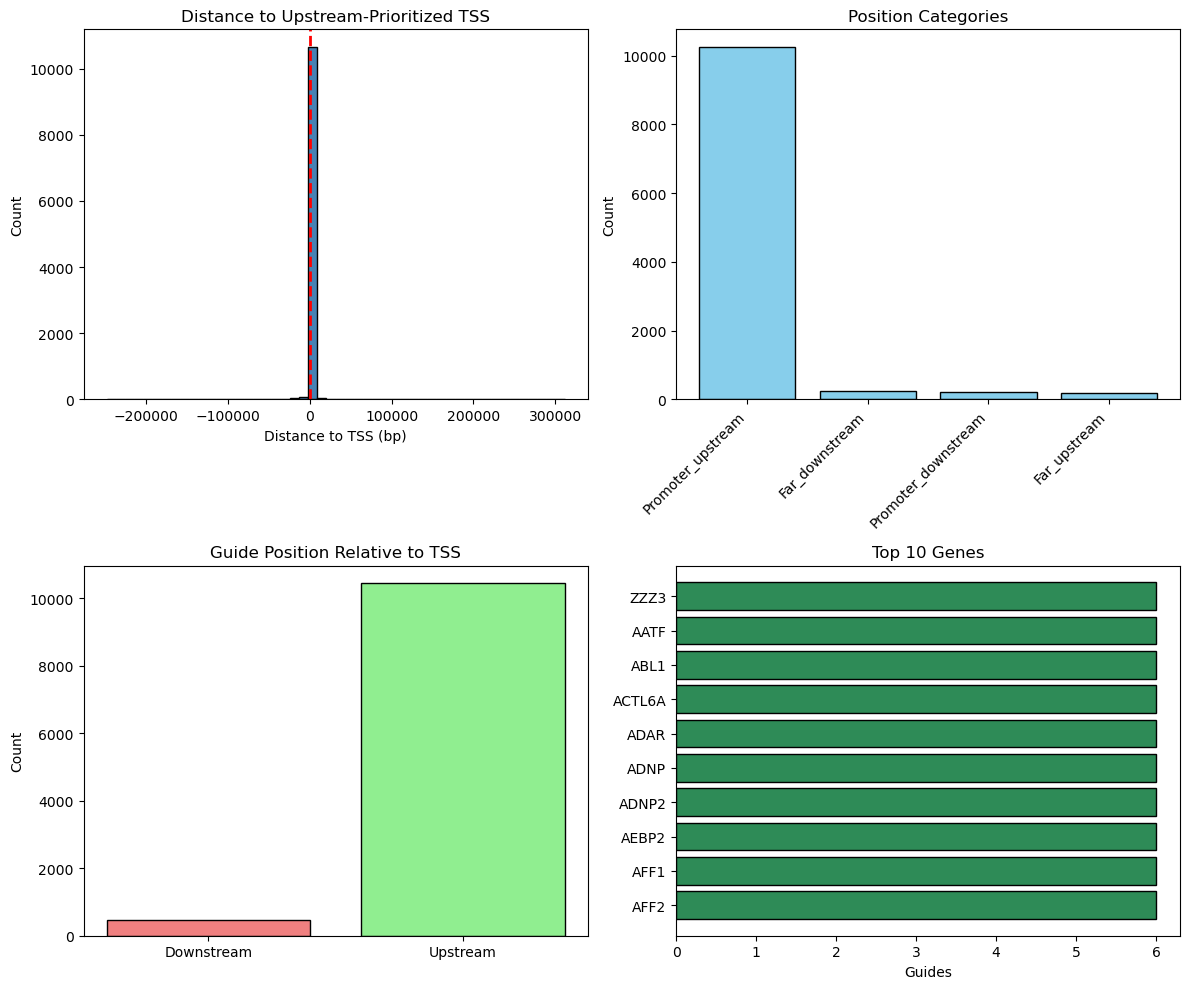

In [8]:
# ============================================================================
# CRISPR Guide Library Analysis: Upstream-Prioritized TSS Annotation (FIXED)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: Load data
tss = pd.read_csv('morf_CRISPRa_mapping_02092024.csv', index_col=0)
guide_lib = pd.read_excel('Supplementary_Table1.xlsx', sheet_name='Table S1 CRISPRa TF library')
guide_lib.set_index('guide_identity', inplace=True)

print(f"Loaded: {len(guide_lib)} guides, {len(tss)} TSS entries")

# Reset TSS index
tss = tss.reset_index(drop=True)

# STEP 2: For each guide, find closest upstream TSS
results = []

for guide_id, guide in guide_lib.iterrows():
    proto = guide['protospacer']
    guide_pos = guide['Start']
    
    tss_matches = tss[tss['protospacer'] == proto].copy()
    
    if len(tss_matches) == 0:
        continue
    
    tss_matches['distance'] = guide_pos - tss_matches['Start_TSS']
    
    # Find upstream TSS based on TSS strand (FIXED)
    upstream_tss_list = []
    for idx, tss_row in tss_matches.iterrows():
        if tss_row['Strand_TSS'] == '+':
            # Positive strand: upstream = negative distance
            if tss_row['distance'] < 0:
                upstream_tss_list.append(idx)
        else:
            # Negative strand: upstream = positive distance
            if tss_row['distance'] > 0:
                upstream_tss_list.append(idx)
    
    if len(upstream_tss_list) > 0:
        upstream_tss = tss_matches.loc[upstream_tss_list]
        idx = upstream_tss['distance'].abs().idxmin()
        is_up = True
    else:
        idx = tss_matches['distance'].abs().idxmin()
        is_up = False
    
    best_row = tss_matches.loc[idx]
    
    # Calculate promoter
    if best_row['Strand_TSS'] == '+':
        prom_start = max(0, best_row['Start_TSS'] - 1000)
        prom_end = best_row['Start_TSS'] + 500
    else:
        prom_start = max(0, best_row['Start_TSS'] - 500)
        prom_end = best_row['Start_TSS'] + 1000
    
    results.append({
        'guide_identity': guide_id,
        'tss_start': best_row['Start_TSS'],
        'tss_end': best_row['End_TSS'],
        'tss_strand': best_row['Strand_TSS'],
        'tss_distance': best_row['distance'],
        'promoter_start': prom_start,
        'promoter_end': prom_end,
        'n_tss_options': len(tss_matches),
        'is_upstream': is_up
    })

tss_annot = pd.DataFrame(results).set_index('guide_identity')

# STEP 3: Merge
merged = guide_lib.join(tss_annot)

print(f"\nMerged: {len(merged)} guides")
print(f"Upstream of TSS: {merged['is_upstream'].sum()} ({merged['is_upstream'].mean()*100:.1f}%)")

# STEP 4: Calculate metrics
merged['in_promoter'] = (
    (merged['Start'] >= merged['promoter_start']) & 
    (merged['Start'] <= merged['promoter_end'])
)

def categorize_position(row):
    dist = row['tss_distance']
    strand = row['tss_strand']
    
    if strand == '+':
        if dist < -1000: return 'Far_upstream'
        elif dist < 0: return 'Promoter_upstream'
        elif dist < 500: return 'Promoter_downstream'
        else: return 'Far_downstream'
    else:
        if dist > 1000: return 'Far_upstream'
        elif dist > 0: return 'Promoter_upstream'
        elif dist >= -500: return 'Promoter_downstream'
        else: return 'Far_downstream'

merged['position_category'] = merged.apply(categorize_position, axis=1)

# STEP 5: Summary
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Total guides: {len(merged)}")
print(f"In promoter: {merged['in_promoter'].sum()} ({merged['in_promoter'].mean()*100:.1f}%)")
print(f"Upstream of TSS: {merged['is_upstream'].sum()} ({merged['is_upstream'].mean()*100:.1f}%)")

print("\nPosition distribution:")
for cat in ['Promoter_upstream', 'Promoter_downstream', 'Far_upstream', 'Far_downstream']:
    count = (merged['position_category'] == cat).sum()
    print(f"  {cat:25s}: {count:5d} ({count/len(merged)*100:5.1f}%)")

multi = merged[merged['n_tss_options'] > 1]
print(f"\nGuides with multiple TSS: {len(multi)} ({len(multi)/len(merged)*100:.1f}%)")
print(f"  Prioritized to upstream: {multi['is_upstream'].sum()}")

# STEP 6: Save
merged.to_csv('merged_guides_UPSTREAM_PRIORITIZED.csv')
print("\n✓ Saved: merged_guides_UPSTREAM_PRIORITIZED.csv")

# STEP 7: Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].hist(merged['tss_distance'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Distance to TSS (bp)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Distance to Upstream-Prioritized TSS')

pos_counts = merged['position_category'].value_counts()
axes[0,1].bar(range(len(pos_counts)), pos_counts.values, color='skyblue', edgecolor='black')
axes[0,1].set_xticks(range(len(pos_counts)))
axes[0,1].set_xticklabels(pos_counts.index, rotation=45, ha='right')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Position Categories')

upstream_total = merged['position_category'].isin(['Promoter_upstream', 'Far_upstream']).sum()
downstream_total = merged['position_category'].isin(['Promoter_downstream', 'Far_downstream']).sum()
axes[1,0].bar(['Downstream', 'Upstream'], 
              [downstream_total, upstream_total],
              color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Guide Position Relative to TSS')

gene_summary = merged.groupby('gene').agg({'protospacer': 'count'}).sort_values('protospacer', ascending=False).head(10)
axes[1,1].barh(range(len(gene_summary)), gene_summary['protospacer'], color='seagreen', edgecolor='black')
axes[1,1].set_yticks(range(len(gene_summary)))
axes[1,1].set_yticklabels(gene_summary.index)
axes[1,1].set_xlabel('Guides')
axes[1,1].set_title('Top 10 Genes')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('upstream_prioritized_summary.png', dpi=300, bbox_inches='tight')
print("✓ Saved: upstream_prioritized_summary.png")
print("\nDONE!")

In [5]:
# ============================================================================
# CRISPR Guide Library Analysis: Upstream-Prioritized TSS Annotation
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: Load data
tss = pd.read_csv('morf_CRISPRa_mapping_02092024.csv', index_col=0)
guide_lib = pd.read_excel('Supplementary_Table1.xlsx', sheet_name='Table S1 CRISPRa TF library')
guide_lib.set_index('guide_identity', inplace=True)

print(f"Loaded: {len(guide_lib)} guides, {len(tss)} TSS entries")
print(f"TSS has {tss.index.duplicated().sum()} duplicate indices")

# STEP 2: Reset TSS index to avoid duplicate index issues
tss = tss.reset_index(drop=True)

# STEP 3: For each guide, find closest upstream TSS
results = []

for guide_id, guide in guide_lib.iterrows():
    proto = guide['protospacer']
    guide_pos = guide['Start']
    strand = guide['Strand']
    
    tss_matches = tss[tss['protospacer'] == proto].copy()
    
    if len(tss_matches) == 0:
        continue
    
    tss_matches['distance'] = guide_pos - tss_matches['Start_TSS']
    
    if strand == '+':
        upstream_tss = tss_matches[tss_matches['distance'] < 0]
    else:
        upstream_tss = tss_matches[tss_matches['distance'] > 0]
    
    if len(upstream_tss) > 0:
        idx = upstream_tss['distance'].abs().idxmin()
        is_up = True
    else:
        idx = tss_matches['distance'].abs().idxmin()
        is_up = False
    
    # Get row as Series
    best_row = tss_matches.loc[idx]
    
    # Calculate promoter
    if best_row['Strand_TSS'] == '+':
        prom_start = max(0, best_row['Start_TSS'] - 1000)
        prom_end = best_row['Start_TSS'] + 500
    else:
        prom_start = max(0, best_row['Start_TSS'] - 500)
        prom_end = best_row['Start_TSS'] + 1000
    
    results.append({
        'guide_identity': guide_id,
        'tss_start': best_row['Start_TSS'],
        'tss_end': best_row['End_TSS'],
        'tss_strand': best_row['Strand_TSS'],
        'tss_distance': best_row['distance'],
        'promoter_start': prom_start,
        'promoter_end': prom_end,
        'n_tss_options': len(tss_matches),
        'is_upstream': is_up
    })

tss_annot = pd.DataFrame(results).set_index('guide_identity')

# STEP 4: Merge
merged = guide_lib.join(tss_annot)

print(f"\nMerged: {len(merged)} guides")
print(f"Upstream of TSS: {merged['is_upstream'].sum()} ({merged['is_upstream'].mean()*100:.1f}%)")

# STEP 5: Calculate metrics
merged['in_promoter'] = (
    (merged['Start'] >= merged['promoter_start']) & 
    (merged['Start'] <= merged['promoter_end'])
)

merged['distance_from_promoter_start'] = merged['Start'] - merged['promoter_start']

def categorize_position(row):
    dist = row['tss_distance']
    strand = row['tss_strand']
    
    if strand == '+':
        if dist < -1000: return 'Far_upstream'
        elif dist < 0: return 'Promoter_upstream'
        elif dist < 500: return 'Promoter_downstream'
        else: return 'Far_downstream'
    else:
        if dist > 1000: return 'Far_upstream'
        elif dist > 0: return 'Promoter_upstream'
        elif dist >= -500: return 'Promoter_downstream'
        else: return 'Far_downstream'

merged['position_category'] = merged.apply(categorize_position, axis=1)

# STEP 6: Summary
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Total guides: {len(merged)}")
print(f"In promoter: {merged['in_promoter'].sum()} ({merged['in_promoter'].mean()*100:.1f}%)")
print(f"Upstream of TSS: {merged['is_upstream'].sum()} ({merged['is_upstream'].mean()*100:.1f}%)")

print("\nPosition distribution:")
for cat, count in merged['position_category'].value_counts().items():
    print(f"  {cat:25s}: {count:5d} ({count/len(merged)*100:5.1f}%)")

multi = merged[merged['n_tss_options'] > 1]
print(f"\nGuides with multiple TSS: {len(multi)} ({len(multi)/len(merged)*100:.1f}%)")
print(f"  Prioritized to upstream: {multi['is_upstream'].sum()}")

# STEP 7: Save
merged.to_csv('merged_guides_UPSTREAM_PRIORITIZED.csv')
print("\n✓ Saved: merged_guides_UPSTREAM_PRIORITIZED.csv")

# STEP 8: Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].hist(merged['tss_distance'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Distance to TSS (bp)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Distance to Upstream-Prioritized TSS')

pos_counts = merged['position_category'].value_counts()
axes[0,1].bar(range(len(pos_counts)), pos_counts.values, color='skyblue', edgecolor='black')
axes[0,1].set_xticks(range(len(pos_counts)))
axes[0,1].set_xticklabels(pos_counts.index, rotation=45, ha='right')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Position Categories')

upstream_counts = merged['is_upstream'].value_counts()
axes[1,0].bar(['Downstream', 'Upstream'], 
              [upstream_counts.get(False, 0), upstream_counts.get(True, 0)],
              color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Guide Position Relative to TSS')

gene_summary = merged.groupby('gene').agg({
    'protospacer': 'count',
    'in_promoter': 'sum',
    'is_upstream': 'sum'
}).sort_values('protospacer', ascending=False).head(10)
axes[1,1].barh(range(len(gene_summary)), gene_summary['protospacer'], 
               color='seagreen', edgecolor='black')
axes[1,1].set_yticks(range(len(gene_summary)))
axes[1,1].set_yticklabels(gene_summary.index)
axes[1,1].set_xlabel('Guides')
axes[1,1].set_title('Top 10 Genes')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('upstream_prioritized_summary.png', dpi=300, bbox_inches='tight')
print("✓ Saved: upstream_prioritized_summary.png")
print("\nDONE!")

DIAGNOSTICS

TSS dataframe:
  Shape: (13814, 13)
  Index name: None
  Duplicate indices: 2910
  Columns: ['gene', 'Chromosome', 'Start', 'End', 'Strand', 'protospacer', 'sequence', 'Start_TSS', 'End_TSS', 'Strand_TSS', 'distance_to_refSeqTSS', 'relative_distance', 'exact_match']

Guide library:
  Shape: (10904, 14)
  Index name: guide_identity
  Duplicate indices: 0

Test with first guide:
  Guide ID: AATF_GGAAGCGCGCAGAAGGTTGA
  Protospacer: GGAAGCGCGCAGAAGGTTGA
  Position: 36948881
  Strand: -

Matching TSS entries: 1
  TSS matches shape: (1, 13)
  TSS matches index: ['AATF_GGAAGCGCGCAGAAGGTTGA']
  Duplicate indices in matches: 0
  Upstream TSS entries: 0

Selected index: AATF_GGAAGCGCGCAGAAGGTTGA
  Type: <class 'str'>

Trying to access values:
  tss_matches.loc[idx, 'Start_TSS']:
    Type: <class 'numpy.int64'>
    Value: 36948953


In [41]:
# Check for duplicates
tss_dup_count = tss['protospacer'].duplicated().sum()
print(f"\nDuplicate protospacers in TSS file: {tss_dup_count}")

if tss_dup_count > 0:
    print("\nFound duplicates - will keep best TSS annotation per protospacer")
    
    # Strategy: Keep the TSS with smallest absolute distance_to_refSeqTSS
    # This keeps the TSS closest to each guide
    
    print("\nStrategy: Keep TSS with smallest distance_to_refSeqTSS for each protospacer")
    
    # Sort by absolute distance and keep first (smallest)
    tss['abs_distance'] = tss['distance_to_refSeqTSS'].abs()
    tss_dedup = tss.sort_values('abs_distance').drop_duplicates(
        subset='protospacer', 
        keep='first'
    ).drop(columns=['abs_distance'])
    
    print(f"✓ Deduplicated TSS: {len(tss_dedup)} entries (removed {len(tss) - len(tss_dedup)})")
    
    # Show what was removed
    removed = len(tss) - len(tss_dedup)
    print(f"  Removed {removed} entries with larger TSS distances")
    
else:
    print("\n✓ No duplicates - TSS file is clean")
    tss_dedup = tss


Duplicate protospacers in TSS file: 2910

Found duplicates - will keep best TSS annotation per protospacer

Strategy: Keep TSS with smallest distance_to_refSeqTSS for each protospacer
✓ Deduplicated TSS: 10904 entries (removed 2910)
  Removed 2910 entries with larger TSS distances


In [42]:
merged = guide_lib.merge(
    tss_dedup[['protospacer', 'Start_TSS', 'End_TSS', 'Strand_TSS', 
               'distance_to_refSeqTSS', 'relative_distance', 'exact_match']],
    on='protospacer',
    how='left'
)

print(f"\n✓ Merge complete: {len(merged)} rows")
print(f"  Matches original guide library: {len(merged) == len(guide_lib)}")

# Verify no duplicates
assert len(merged) == len(guide_lib), "ERROR: Merged dataframe has different length!"
assert merged.index.duplicated().sum() == 0, "ERROR: Duplicate guide_identities found!"

print("✓ No duplicates - perfect 1:1 mapping!")


✓ Merge complete: 10904 rows
  Matches original guide library: True
✓ No duplicates - perfect 1:1 mapping!


In [47]:
# EXPANDED WINDOW: -1000 to +500 bp from TSS
# Positive strand: TSS - 1000 to TSS + 500
merged.loc[merged['Strand_TSS'] == '+', 'promoter_start'] = (
    merged.loc[merged['Strand_TSS'] == '+', 'Start_TSS'] - 1000
)
merged.loc[merged['Strand_TSS'] == '+', 'promoter_end'] = (
    merged.loc[merged['Strand_TSS'] == '+', 'Start_TSS'] + 500
)

# Negative strand: TSS - 500 to TSS + 1000
# (upstream on negative strand is higher coordinates)
merged.loc[merged['Strand_TSS'] == '-', 'promoter_start'] = (
    merged.loc[merged['Strand_TSS'] == '-', 'Start_TSS'] - 500
)
merged.loc[merged['Strand_TSS'] == '-', 'promoter_end'] = (
    merged.loc[merged['Strand_TSS'] == '-', 'Start_TSS'] + 1000
)

# Handle negative coordinates
neg_coords = merged['promoter_start'] < 0
if neg_coords.sum() > 0:
    print(f"\n⚠ Setting {neg_coords.sum()} negative promoter_start values to 0")
    merged.loc[neg_coords, 'promoter_start'] = 0

# Calculate promoter width for verification
merged['promoter_width'] = merged['promoter_end'] - merged['promoter_start']
print(f"\n✓ Promoter regions calculated")
print(f"   Average promoter width: {merged['promoter_width'].mean():.0f} bp")
print(f"   (Expected: 1500 bp, may vary due to negative coordinate handling)")


✓ Promoter regions calculated
   Average promoter width: 1500 bp
   (Expected: 1500 bp, may vary due to negative coordinate handling)


In [48]:
# Distance from promoter start
merged['distance_from_promoter_start'] = merged['Start'] - merged['promoter_start']

# Flag guides within promoter
merged['in_promoter'] = (
    (merged['Start'] >= merged['promoter_start']) & 
    (merged['Start'] <= merged['promoter_end'])
)

# Verify TSS distance
merged['calculated_tss_distance'] = merged['Start'] - merged['Start_TSS']

# Additional useful metrics for expanded window
# Position relative to TSS (negative = upstream, positive = downstream)
merged['position_relative_to_tss'] = merged['Start'] - merged['Start_TSS']

# Categorize position
def categorize_position(row):
    if pd.isna(row['position_relative_to_tss']):
        return 'Unknown'
    dist = row['position_relative_to_tss']
    strand = row['Strand_TSS']
    
    # Account for strand
    if strand == '+':
        if dist < -1000:
            return 'Far_upstream'
        elif -1000 <= dist < 0:
            return 'Promoter_upstream'
        elif 0 <= dist < 500:
            return 'Promoter_downstream'
        else:
            return 'Far_downstream'
    else:  # negative strand
        if dist > 1000:
            return 'Far_upstream'
        elif 0 < dist <= 1000:
            return 'Promoter_upstream'
        elif -500 <= dist <= 0:
            return 'Promoter_downstream'
        else:
            return 'Far_downstream'

merged['position_category'] = merged.apply(categorize_position, axis=1)

print(f"✓ Metrics calculated")


✓ Metrics calculated


In [49]:
print(f"\nDataframe: {len(merged)} rows")
print(f"Guides with TSS annotations: {merged['Start_TSS'].notna().sum()}")
print(f"Guides in promoter regions: {merged['in_promoter'].sum()} ({merged['in_promoter'].mean()*100:.1f}%)")

print("\n📊 Position Distribution:")
pos_dist = merged['position_category'].value_counts()
for cat, count in pos_dist.items():
    pct = count / len(merged) * 100
    print(f"   {cat:25s}: {count:5d} ({pct:5.1f}%)")

print("\n📈 Comparison with Original 500bp Window:")
print("   Old definition: -500 to 0 bp (500 bp total)")
print("   New definition: -1000 to +500 bp (1500 bp total)")
print("   → 3x larger window")
print("   → More guides expected in promoter regions")

# Calculate what would have been in old window
merged['in_old_promoter'] = False
# Positive strand: [-500, TSS]
old_pos = (merged['Strand_TSS'] == '+') & \
          (merged['Start'] >= merged['Start_TSS'] - 500) & \
          (merged['Start'] <= merged['Start_TSS'])
# Negative strand: [TSS, TSS+500]
old_neg = (merged['Strand_TSS'] == '-') & \
          (merged['Start'] >= merged['Start_TSS']) & \
          (merged['Start'] <= merged['Start_TSS'] + 500)
merged.loc[old_pos | old_neg, 'in_old_promoter'] = True

old_count = merged['in_old_promoter'].sum()
new_count = merged['in_promoter'].sum()
print(f"\n   Guides in old window (-500 to 0): {old_count} ({old_count/len(merged)*100:.1f}%)")
print(f"   Guides in NEW window (-1000 to +500): {new_count} ({new_count/len(merged)*100:.1f}%)")
print(f"   Additional guides captured: {new_count - old_count} (+{(new_count-old_count)/old_count*100:.1f}%)")

# Per-gene summary
print("\n📋 Top genes by guide count:")
gene_summary = merged.groupby('gene').agg({
    'protospacer': 'count',
    'in_promoter': 'sum',
    'in_old_promoter': 'sum'
}).round(2)
gene_summary.columns = ['Total', 'New_window', 'Old_window']
gene_summary['New_pct'] = (gene_summary['New_window'] / gene_summary['Total'] * 100).round(1)
gene_summary['Old_pct'] = (gene_summary['Old_window'] / gene_summary['Total'] * 100).round(1)
gene_summary = gene_summary.sort_values('Total', ascending=False)
print(gene_summary.head(10).to_string())


Dataframe: 10904 rows
Guides with TSS annotations: 10904
Guides in promoter regions: 10568 (96.9%)

📊 Position Distribution:
   Promoter_upstream        :  9910 ( 90.9%)
   Promoter_downstream      :   658 (  6.0%)
   Far_downstream           :   252 (  2.3%)
   Far_upstream             :    84 (  0.8%)

📈 Comparison with Original 500bp Window:
   Old definition: -500 to 0 bp (500 bp total)
   New definition: -1000 to +500 bp (1500 bp total)
   → 3x larger window
   → More guides expected in promoter regions

   Guides in old window (-500 to 0): 9817 (90.0%)
   Guides in NEW window (-1000 to +500): 10568 (96.9%)
   Additional guides captured: 751 (+7.6%)

📋 Top genes by guide count:
        Total  New_window  Old_window  New_pct  Old_pct
gene                                                   
ZZZ3        6           6           3    100.0     50.0
AATF        6           6           6    100.0    100.0
ABL1        6           2           2     33.3     33.3
ACTL6A      6           6  

In [51]:

# Drop temporary column
merged = merged.drop(columns=['in_old_promoter', 'promoter_width'])

merged.to_csv('merged_guides_EXPANDED_PROMOTER_1000up_500down.csv')
print("✓ Saved: merged_guides_EXPANDED_PROMOTER_1000up_500down.csv")

# Generate BED file with expanded promoters
promoter_bed = merged[['Chromosome', 'promoter_start', 'promoter_end', 
                       'gene', 'Strand_TSS']].drop_duplicates()
promoter_bed['name'] = promoter_bed['gene'] + '_promoter_expanded'
promoter_bed['score'] = 0
promoter_bed = promoter_bed[['Chromosome', 'promoter_start', 'promoter_end', 
                             'name', 'score', 'Strand_TSS']]
promoter_bed = promoter_bed.sort_values(['Chromosome', 'promoter_start'])
promoter_bed.to_csv('promoter_regions_EXPANDED.bed', sep='\t', header=False, index=False)
print("✓ Saved: promoter_regions_EXPANDED.bed")

# Save summary
gene_summary.to_csv('gene_summary_EXPANDED_window.csv')
print("✓ Saved: gene_summary_EXPANDED_window.csv")

print("\n" + "="*80)
print("✓ COMPLETE - EXPANDED PROMOTER WINDOW")
print("="*80)
print("\nFiles created:")
print("  1. merged_guides_EXPANDED_PROMOTER_1000up_500down.csv")
print("  2. promoter_regions_EXPANDED.bed")
print("  3. gene_summary_EXPANDED_window.csv")
print("\nPromoter window: -1000 to +500 bp from TSS (1500 bp total)")
print("="*80)

✓ Saved: merged_guides_EXPANDED_PROMOTER_1000up_500down.csv
✓ Saved: promoter_regions_EXPANDED.bed
✓ Saved: gene_summary_EXPANDED_window.csv

✓ COMPLETE - EXPANDED PROMOTER WINDOW

Files created:
  1. merged_guides_EXPANDED_PROMOTER_1000up_500down.csv
  2. promoter_regions_EXPANDED.bed
  3. gene_summary_EXPANDED_window.csv

Promoter window: -1000 to +500 bp from TSS (1500 bp total)


In [52]:
# Load data
print("\nLoading data...")
tss_original = pd.read_csv('morf_CRISPRa_mapping_02092024.csv', index_col=0)
merged = pd.read_csv('merged_guides_EXPANDED_PROMOTER_1000up_500down.csv')

# Get downstream guides
downstream = merged[merged['position_category'] == 'Promoter_downstream']
print(f"✓ Found {len(downstream)} downstream guides")

# Check for multiple TSSs in original file
print(f"\nChecking original TSS file...")
print(f"  Total TSS entries: {len(tss_original)}")
print(f"  Unique protospacers: {tss_original['protospacer'].nunique()}")

# Do we have multiple TSSs per protospacer?
tss_per_proto = tss_original.groupby('protospacer').size()
multi_tss = tss_per_proto[tss_per_proto > 1]

print(f"\n🔍 ANSWER:")
if len(multi_tss) > 0:
    print(f"   ✓ YES - {len(multi_tss)} protospacers have multiple TSS annotations")
    print(f"   Range: {multi_tss.min()}-{multi_tss.max()} TSSs per protospacer")
    
    # Check downstream guides specifically
    downstream_protos = set(downstream['protospacer'].unique())
    downstream_with_multi = [p for p in downstream_protos if p in multi_tss.index]
    
    print(f"\n   Downstream guides with multiple TSSs: {len(downstream_with_multi)}")
    print(f"   That's {len(downstream_with_multi)/len(downstream)*100:.1f}% of downstream guides")
    
    if len(downstream_with_multi) > 0:
        print(f"\n   💡 These guides might be upstream of an alternative TSS!")
        print(f"   Run 'python analyze_alternative_tss.py' for detailed analysis")
else:
    print(f"   ✗ NO - Each protospacer has only one TSS annotation")
    print(f"   Downstream guides are genuinely downstream")
    print(f"\n   These guides may target:")
    print(f"   - Downstream regulatory elements")
    print(f"   - 5' UTR regions") 
    print(f"   - TSS-proximal enhancers (+0 to +500 bp)")

print("\n" + "="*70)


Loading data...
✓ Found 658 downstream guides

Checking original TSS file...
  Total TSS entries: 13814
  Unique protospacers: 10904

🔍 ANSWER:
   ✓ YES - 2659 protospacers have multiple TSS annotations
   Range: 2-10 TSSs per protospacer

   Downstream guides with multiple TSSs: 457
   That's 69.5% of downstream guides

   💡 These guides might be upstream of an alternative TSS!
   Run 'python analyze_alternative_tss.py' for detailed analysis



In [53]:
"""
ALTERNATIVE TSS ANALYSIS

Check if guides downstream of their assigned TSS could be upstream 
of an alternative TSS (different transcript isoform).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("ALTERNATIVE TSS ANALYSIS FOR DOWNSTREAM GUIDES")
print("="*80)

# =============================================================================
# STEP 1: LOAD DATA
# =============================================================================
print("\nSTEP 1: Loading data...")

# Load the ORIGINAL TSS file (before deduplication)
# This contains ALL TSS entries, including alternatives
tss_original = pd.read_csv('morf_CRISPRa_mapping_02092024.csv', index_col=0)
print(f"✓ Original TSS data: {len(tss_original)} entries")

# Load merged data with expanded promoter
merged = pd.read_csv('merged_guides_EXPANDED_PROMOTER_1000up_500down.csv')
if 'guide_identity' in merged.columns:
    merged = merged.set_index('guide_identity')
print(f"✓ Merged data: {len(merged)} guides")

# =============================================================================
# STEP 2: IDENTIFY DOWNSTREAM GUIDES
# =============================================================================
print("\n" + "="*80)
print("STEP 2: Identifying downstream guides")
print("="*80)

# Get guides in downstream category
downstream_guides = merged[merged['position_category'] == 'Promoter_downstream'].copy()
print(f"\nGuides downstream of TSS: {len(downstream_guides)} ({len(downstream_guides)/len(merged)*100:.1f}%)")

print("\nBreakdown by gene (top 20):")
downstream_by_gene = downstream_guides.groupby('gene').size().sort_values(ascending=False)
print(downstream_by_gene.head(20))

# =============================================================================
# STEP 3: CHECK FOR ALTERNATIVE TSS
# =============================================================================
print("\n" + "="*80)
print("STEP 3: Checking for alternative TSS annotations")
print("="*80)

print("\nFor each downstream guide, checking if alternative TSS exists where guide is upstream...")

# For each downstream guide, find ALL TSS entries in original file
results = []

for guide_id, guide_row in downstream_guides.iterrows():
    protospacer = guide_row['protospacer']
    guide_pos = guide_row['Start']
    assigned_tss = guide_row['Start_TSS']
    strand = guide_row['Strand_TSS']
    gene = guide_row['gene']
    
    # Find all TSS entries for this protospacer
    all_tss = tss_original[tss_original['protospacer'] == protospacer]
    
    if len(all_tss) > 1:
        # Multiple TSS entries exist!
        
        # Check each alternative TSS
        for idx, tss_row in all_tss.iterrows():
            alt_tss = tss_row['Start_TSS']
            alt_distance = guide_pos - alt_tss
            
            # Is guide upstream of this alternative TSS?
            if strand == '+':
                is_upstream = alt_distance < 0
            else:  # negative strand
                is_upstream = alt_distance > 0
            
            # Is this alternative TSS different from assigned TSS?
            if alt_tss != assigned_tss:
                results.append({
                    'guide_identity': guide_id,
                    'gene': gene,
                    'protospacer': protospacer,
                    'guide_position': guide_pos,
                    'assigned_TSS': assigned_tss,
                    'assigned_distance': guide_row['position_relative_to_tss'],
                    'alternative_TSS': alt_tss,
                    'alternative_distance': alt_distance,
                    'strand': strand,
                    'is_upstream_of_alt': is_upstream,
                    'total_TSS_for_guide': len(all_tss)
                })

# Create results dataframe
if results:
    alt_tss_df = pd.DataFrame(results)
    
    print(f"\n✓ Found {len(alt_tss_df)} alternative TSS annotations")
    print(f"  Unique guides with alternatives: {alt_tss_df['guide_identity'].nunique()}")
    print(f"  Guides upstream of alternative TSS: {alt_tss_df['is_upstream_of_alt'].sum()}")
    
    # Which guides are upstream of alternative TSS?
    upstream_of_alt = alt_tss_df[alt_tss_df['is_upstream_of_alt']]
    
    if len(upstream_of_alt) > 0:
        print(f"\n🎯 KEY FINDING: {len(upstream_of_alt)} downstream guides are UPSTREAM of alternative TSS!")
        print(f"   These represent {upstream_of_alt['guide_identity'].nunique()} unique guides")
        print(f"   Percent of downstream guides: {upstream_of_alt['guide_identity'].nunique()/len(downstream_guides)*100:.1f}%")
        
        print("\n   Top genes with this pattern:")
        alt_genes = upstream_of_alt.groupby('gene').size().sort_values(ascending=False)
        print(alt_genes.head(10))
else:
    print("\n⚠ No alternative TSS annotations found in original TSS file")
    print("   This could mean:")
    print("   1. TSS file only contains one TSS per protospacer")
    print("   2. Deduplication removed all alternatives")
    alt_tss_df = pd.DataFrame()
    upstream_of_alt = pd.DataFrame()

# =============================================================================
# STEP 4: DETAILED ANALYSIS
# =============================================================================
print("\n" + "="*80)
print("STEP 4: Detailed analysis of alternative TSS patterns")
print("="*80)

if len(alt_tss_df) > 0:
    # Statistics on alternative TSS distances
    print("\n📊 Distance statistics:")
    print(f"   Assigned TSS distance (downstream): {alt_tss_df['assigned_distance'].mean():.1f} bp (mean)")
    print(f"   Alternative TSS distance: {alt_tss_df['alternative_distance'].mean():.1f} bp (mean)")
    
    # How far apart are the alternative TSSs?
    alt_tss_df['TSS_difference'] = abs(alt_tss_df['alternative_TSS'] - alt_tss_df['assigned_TSS'])
    print(f"   Distance between TSSs: {alt_tss_df['TSS_difference'].mean():.1f} bp (mean)")
    print(f"                          {alt_tss_df['TSS_difference'].median():.1f} bp (median)")
    
    # Distribution of TSS per guide
    print("\n📊 Number of alternative TSSs per guide:")
    tss_counts = alt_tss_df.groupby('guide_identity')['total_TSS_for_guide'].first().value_counts().sort_index()
    for n_tss, count in tss_counts.items():
        print(f"   {n_tss} TSSs: {count} guides")
    
    # Save detailed results
    alt_tss_df.to_csv('alternative_TSS_analysis.csv', index=False)
    print("\n✓ Saved: alternative_TSS_analysis.csv")
    
    # Save just the guides upstream of alternative TSS
    if len(upstream_of_alt) > 0:
        upstream_of_alt.to_csv('downstream_guides_with_upstream_alternatives.csv', index=False)
        print("✓ Saved: downstream_guides_with_upstream_alternatives.csv")

# =============================================================================
# STEP 5: CHECK ORIGINAL TSS FILE FOR DUPLICATES
# =============================================================================
print("\n" + "="*80)
print("STEP 5: Original TSS file structure")
print("="*80)

print(f"\nOriginal TSS file statistics:")
print(f"  Total entries: {len(tss_original)}")
print(f"  Unique protospacers: {tss_original['protospacer'].nunique()}")
print(f"  Entries per protospacer: {len(tss_original) / tss_original['protospacer'].nunique():.2f} (average)")

# Check which protospacers have multiple TSSs
multi_tss = tss_original.groupby('protospacer').size()
multi_tss = multi_tss[multi_tss > 1].sort_values(ascending=False)

print(f"\nProtospacers with multiple TSS annotations: {len(multi_tss)}")
if len(multi_tss) > 0:
    print(f"  Range: {multi_tss.min()} to {multi_tss.max()} TSSs per protospacer")
    print(f"\n  Top 10 protospacers by number of TSSs:")
    for proto, count in multi_tss.head(10).items():
        print(f"    {proto[:20]}... : {count} TSSs")

# =============================================================================
# STEP 6: VISUALIZATION
# =============================================================================
print("\n" + "="*80)
print("STEP 6: Generating visualizations")
print("="*80)

if len(alt_tss_df) > 0 and len(upstream_of_alt) > 0:
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Distance comparison
    ax = axes[0, 0]
    data_to_plot = [
        alt_tss_df['assigned_distance'].dropna(),
        alt_tss_df['alternative_distance'].dropna()
    ]
    ax.boxplot(data_to_plot, labels=['Assigned TSS\n(downstream)', 'Alternative TSS'])
    ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('Distance to TSS (bp)', fontsize=11)
    ax.set_title('Distance Distribution: Assigned vs Alternative TSS', 
                fontsize=12, weight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # 2. TSS separation distance
    ax = axes[0, 1]
    ax.hist(alt_tss_df['TSS_difference'].dropna(), bins=30, 
            color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Distance Between TSSs (bp)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Distance Between Assigned and Alternative TSS', 
                fontsize=12, weight='bold')
    ax.axvline(alt_tss_df['TSS_difference'].median(), 
               color='red', linestyle='--', linewidth=2,
               label=f"Median: {alt_tss_df['TSS_difference'].median():.0f} bp")
    ax.legend()
    
    # 3. Upstream vs downstream of alternative
    ax = axes[1, 0]
    upstream_count = alt_tss_df['is_upstream_of_alt'].sum()
    downstream_count = (~alt_tss_df['is_upstream_of_alt']).sum()
    bars = ax.bar(['Still Downstream', 'Now Upstream'], 
                  [downstream_count, upstream_count],
                  color=['lightcoral', 'lightgreen'], edgecolor='black')
    ax.set_ylabel('Number of Guides', fontsize=11)
    ax.set_title('Position Relative to Alternative TSS', 
                fontsize=12, weight='bold')
    
    # Add percentages
    total = len(alt_tss_df)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({height/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, weight='bold')
    
    # 4. Per-gene breakdown
    ax = axes[1, 1]
    if len(upstream_of_alt) > 0:
        gene_counts = upstream_of_alt.groupby('gene')['guide_identity'].nunique().sort_values(ascending=False).head(10)
        ax.barh(range(len(gene_counts)), gene_counts.values, 
                color='seagreen', edgecolor='black', alpha=0.7)
        ax.set_yticks(range(len(gene_counts)))
        ax.set_yticklabels(gene_counts.index)
        ax.set_xlabel('Guides Upstream of Alternative TSS', fontsize=11)
        ax.set_title('Top Genes with Alternative TSS Pattern', 
                    fontsize=12, weight='bold')
        ax.invert_yaxis()
    else:
        ax.text(0.5, 0.5, 'No guides upstream\nof alternative TSS',
               ha='center', va='center', fontsize=12)
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('alternative_TSS_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: alternative_TSS_analysis.png")
    plt.close()

# =============================================================================
# STEP 7: EXAMPLE CASES
# =============================================================================
print("\n" + "="*80)
print("STEP 7: Example cases")
print("="*80)

if len(upstream_of_alt) > 0:
    print("\n📋 Example guides downstream of assigned TSS but upstream of alternative:")
    print("-" * 80)
    
    example_cols = ['gene', 'guide_position', 'assigned_TSS', 'assigned_distance',
                   'alternative_TSS', 'alternative_distance', 'strand']
    print(upstream_of_alt[example_cols].head(10).to_string())
    
    # Pick one for detailed explanation
    if len(upstream_of_alt) > 0:
        example = upstream_of_alt.iloc[0]
        print("\n" + "="*60)
        print("DETAILED EXAMPLE:")
        print("="*60)
        print(f"\nGene: {example['gene']}")
        print(f"Guide position: {example['guide_position']}")
        print(f"Strand: {example['strand']}")
        print(f"\nAssigned TSS: {example['assigned_TSS']}")
        print(f"  → Distance: {example['assigned_distance']:+.0f} bp (DOWNSTREAM)")
        print(f"\nAlternative TSS: {example['alternative_TSS']}")
        print(f"  → Distance: {example['alternative_distance']:+.0f} bp (UPSTREAM)")
        print(f"\nTSS difference: {abs(example['alternative_TSS'] - example['assigned_TSS']):.0f} bp apart")
        print("\n💡 This guide appears downstream of one TSS but upstream of another,")
        print("   suggesting it targets an alternative transcript isoform.")

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"\n📊 Overall Statistics:")
print(f"   Total guides: {len(merged)}")
print(f"   Downstream guides: {len(downstream_guides)} ({len(downstream_guides)/len(merged)*100:.1f}%)")

if len(alt_tss_df) > 0:
    n_with_alt = alt_tss_df['guide_identity'].nunique()
    n_upstream_of_alt = upstream_of_alt['guide_identity'].nunique() if len(upstream_of_alt) > 0 else 0
    
    print(f"\n   Downstream guides with alternative TSS: {n_with_alt}")
    print(f"   Downstream guides upstream of alt TSS: {n_upstream_of_alt}")
    print(f"   Percent explained by alt TSS: {n_upstream_of_alt/len(downstream_guides)*100:.1f}%")
    
    if n_upstream_of_alt > 0:
        print("\n✅ CONCLUSION:")
        print(f"   {n_upstream_of_alt} of {len(downstream_guides)} downstream guides ({n_upstream_of_alt/len(downstream_guides)*100:.1f}%)")
        print("   are actually UPSTREAM of an alternative TSS!")
        print("\n   This suggests these guides may be targeting alternative transcript")
        print("   isoforms with different TSSs.")
    else:
        print("\n⚠ CONCLUSION:")
        print("   No downstream guides found to be upstream of alternative TSS.")
        print("   These guides may target:")
        print("   1. Downstream regulatory elements")
        print("   2. 5' UTR regions")
        print("   3. Early coding sequences")
else:
    print("\n⚠ No alternative TSS data available")
    print("   TSS file may contain only one TSS per guide")

print("\n" + "="*80)
print("Files created:")
if len(alt_tss_df) > 0:
    print("  - alternative_TSS_analysis.csv")
    if len(upstream_of_alt) > 0:
        print("  - downstream_guides_with_upstream_alternatives.csv")
    print("  - alternative_TSS_analysis.png")
print("="*80)

ALTERNATIVE TSS ANALYSIS FOR DOWNSTREAM GUIDES

STEP 1: Loading data...
✓ Original TSS data: 13814 entries
✓ Merged data: 10904 guides

STEP 2: Identifying downstream guides

Guides downstream of TSS: 658 (6.0%)

Breakdown by gene (top 20):
gene
ZNF219     6
NKRF       6
ZNF583     5
ZNF165     5
ZNF667     5
RXRB       5
MAX        5
NFE4       5
BID        5
ZNF641     4
LIN28B     4
ZNF33A     4
BCL11B     4
ZMYND11    4
FOXA2      4
ZNF229     4
ZNF384     4
ZNF652     4
ZFHX2      4
MSC        4
dtype: int64

STEP 3: Checking for alternative TSS annotations

For each downstream guide, checking if alternative TSS exists where guide is upstream...

✓ Found 497 alternative TSS annotations
  Unique guides with alternatives: 457
  Guides upstream of alternative TSS: 443

🎯 KEY FINDING: 443 downstream guides are UPSTREAM of alternative TSS!
   These represent 431 unique guides
   Percent of downstream guides: 65.5%

   Top genes with this pattern:
gene
TERB1     8
AEBP2     6
ZNF219    

/tmp/ipykernel_2999176/266027391.py:200: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['Assigned TSS\n(downstream)', 'Alternative TSS'])



✓ Saved: alternative_TSS_analysis.png

STEP 7: Example cases

📋 Example guides downstream of assigned TSS but upstream of alternative:
--------------------------------------------------------------------------------
      gene  guide_position  assigned_TSS  assigned_distance  alternative_TSS  alternative_distance strand
0    AEBP2        19439542      19439491                 51         19440598                 -1056      +
1    AEBP2        19439542      19439491                 51         19443123                 -3581      +
3    AEBP2        19439630      19439491                139         19440598                  -968      +
4    AEBP2        19439630      19439491                139         19443123                 -3493      +
6    AEBP2        19439534      19439491                 43         19440598                 -1064      +
7    AEBP2        19439534      19439491                 43         19443123                 -3589      +
9    AP2B1        35587422      35587321 

In [45]:
# Distance from guide to promoter start
merged['distance_from_promoter_start'] = merged['Start'] - merged['promoter_start']

# Flag guides within promoter region
merged['in_promoter'] = (
    (merged['Start'] >= merged['promoter_start']) & 
    (merged['Start'] <= merged['promoter_end'])
)

# Verify TSS distance calculation
merged['calculated_tss_distance'] = merged['Start'] - merged['Start_TSS']

In [46]:
merged.to_csv('merged_guides_with_promoter_annotations.csv')

print(f"Merged dataframe shape: {merged.shape}")
print(f"Guides in promoter regions: {merged['in_promoter'].sum()}")
print(f"Missing TSS annotations: {merged['Start_TSS'].isna().sum()}")


Merged dataframe shape: (10904, 25)
Guides in promoter regions: 9920
Missing TSS annotations: 0


In [28]:

# Check distance agreement
has_both = merged['distance_to_refSeqTSS'].notna() & merged['calculated_tss_distance'].notna()
distance_match = (
    merged.loc[has_both, 'distance_to_refSeqTSS'] == 
    merged.loc[has_both, 'calculated_tss_distance']
)

print(f"\nTSS distance validation:")
print(f"  Matches: {distance_match.sum()} / {has_both.sum()}")
if not distance_match.all():
    print(f"  ⚠ Mismatches: {(~distance_match).sum()}")
    print("  This may indicate different coordinate systems")
else:
    print("  ✓ All distances match")

# Gene-level summary
print("\n" + "-"*80)
print("Per-gene summary:")
print("-"*80)
gene_summary = merged.groupby('gene').agg({
    'protospacer': 'count',
    'in_promoter': 'sum',
    'distance_to_refSeqTSS': 'mean'
}).round(2)
gene_summary.columns = ['Total', 'In_promoter', 'Avg_TSS_dist']
gene_summary['Pct_in_promoter'] = (gene_summary['In_promoter'] / gene_summary['Total'] * 100).round(1)
gene_summary = gene_summary.sort_values('Total', ascending=False)
print(gene_summary.head(10))

# Library summary
print("\n" + "-"*80)
print("Per-library summary:")
print("-"*80)
lib_summary = merged.groupby('library').agg({
    'protospacer': 'count',
    'in_promoter': 'sum'
})
lib_summary.columns = ['Total', 'In_promoter']
lib_summary['Pct_in_promoter'] = (lib_summary['In_promoter'] / lib_summary['Total'] * 100).round(1)
print(lib_summary)


TSS distance validation:
  Matches: 3383 / 13814
  ⚠ Mismatches: 10431
  This may indicate different coordinate systems

--------------------------------------------------------------------------------
Per-gene summary:
--------------------------------------------------------------------------------
        Total  In_promoter  Avg_TSS_dist  Pct_in_promoter
gene                                                     
ZNF541     36            2     -27903.08              5.6
SOX5       28            4    -150480.57             14.3
ZNF423     28            4      32554.29             14.3
TERB1      28            2       1203.86              7.1
NSD2       26            6     -27750.50             23.1
ZNF831     24            2      29510.00              8.3
ZNF875     24           10       -870.08             41.7
SOX6       21            3     -98757.19             14.3
MEIS3      20            4      -8065.60             20.0
ESRRB      20            2      35354.50             10.0

-


✓ Saved: guide_annotation_summary.png


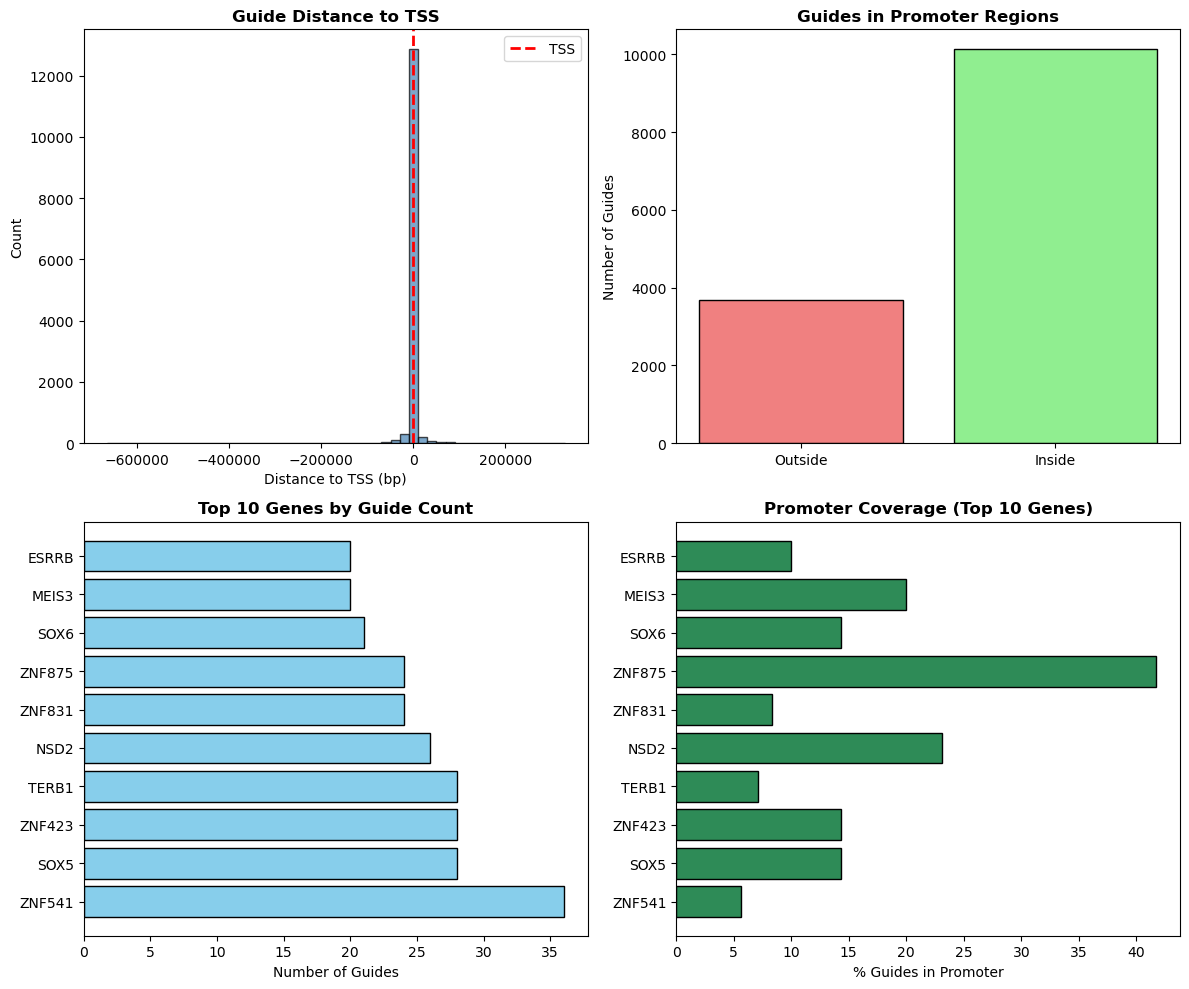

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. TSS distance distribution
axes[0, 0].hist(merged['distance_to_refSeqTSS'].dropna(), bins=50, 
                color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='TSS')
axes[0, 0].set_xlabel('Distance to TSS (bp)', fontsize=10)
axes[0, 0].set_ylabel('Count', fontsize=10)
axes[0, 0].set_title('Guide Distance to TSS', fontsize=12, weight='bold')
axes[0, 0].legend()

# 2. In/out of promoter
in_prom = merged['in_promoter'].value_counts()
axes[0, 1].bar(['Outside', 'Inside'], 
               [in_prom.get(False, 0), in_prom.get(True, 0)],
               color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[0, 1].set_ylabel('Number of Guides', fontsize=10)
axes[0, 1].set_title('Guides in Promoter Regions', fontsize=12, weight='bold')

# 3. Per-gene distribution
top_genes = gene_summary.head(10)
axes[1, 0].barh(top_genes.index, top_genes['Total'], 
                color='skyblue', edgecolor='black')
axes[1, 0].set_xlabel('Number of Guides', fontsize=10)
axes[1, 0].set_title('Top 10 Genes by Guide Count', fontsize=12, weight='bold')

# 4. Promoter coverage per gene
axes[1, 1].barh(top_genes.index, top_genes['Pct_in_promoter'],
                color='seagreen', edgecolor='black')
axes[1, 1].set_xlabel('% Guides in Promoter', fontsize=10)
axes[1, 1].set_title('Promoter Coverage (Top 10 Genes)', fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig('guide_annotation_summary.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: guide_annotation_summary.png")
